In [1]:
import os
import sys

PROJECT_ROOT = os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [2]:
import pandas as pd

peer_df = pd.read_csv("data/processed/peer_percentiles.csv")

peer_df.head()

,company_id,year,net_profit_margin_pct,operating_profit_margin_pct,return_on_equity_pct,debt_to_equity,interest_coverage,asset_turnover,free_cash_flow_cr,capex_cr,...,return_on_equity_pct_percentile,operating_profit_margin_pct_percentile,net_profit_margin_pct_percentile,debt_to_equity_percentile,free_cash_flow_cr_percentile,interest_coverage_percentile,asset_turnover_percentile,market_cap_crore_percentile,pe_ratio_percentile,dividend_yield_pct_percentile
0,ABB,NaN,8.77,12.0,22.41,0.0,NaN,1.8225,42.0,59.0,...,0.692469,0.233753,0.375262,0.951883,0.355649,NaN,0.870021,NaN,NaN,NaN
1,ABB,NaN,8.70,12.0,25.13,0.0,NaN,1.9982,11.0,144.0,...,0.752092,0.233753,0.372117,0.951883,0.342050,NaN,0.881551,NaN,NaN,NaN
2,ABB,NaN,8.70,12.0,25.13,0.0,NaN,1.9982,0.0,0.0,...,0.752092,0.233753,0.372117,0.951883,0.337866,NaN,0.881551,NaN,NaN,NaN
3,ABB,NaN,10.00,14.0,24.44,0.0,NaN,1.6659,28.0,187.0,...,0.735356,0.281971,0.430818,0.951883,0.351464,NaN,0.848008,NaN,NaN,NaN
4,ABB,NaN,10.00,14.0,24.44,0.0,NaN,1.6659,-1899.0,1864.0,...,0.735356,0.281971,0.430818,0.951883,0.176778,NaN,0.848008,NaN,NaN,NaN


In [3]:
peer_df["composite_quality_score"] = (
    peer_df["return_on_equity_pct"].fillna(0) * 0.15 +
    peer_df["operating_profit_margin_pct"].fillna(0) * 0.10 +
    peer_df["net_profit_margin_pct"].fillna(0) * 0.10 +
    peer_df["free_cash_flow_cr"].fillna(0) * 0.15 +
    peer_df["asset_turnover"].fillna(0) * 0.05 +
    (1 / (peer_df["debt_to_equity"].fillna(1) + 1)) * 20 +
    (1 / (peer_df["pe_ratio"].fillna(20) + 1)) * 20 +
    peer_df["interest_coverage"].fillna(0) * 0.05
)

In [4]:
ranking = (
    peer_df.groupby("company_name")
    .agg({
        "composite_quality_score": "mean",
        "market_cap_crore": "mean",
        "return_on_equity_pct": "mean",
        "operating_profit_margin_pct": "mean",
        "free_cash_flow_cr": "mean"
    })
    .sort_values(
        "composite_quality_score",
        ascending=False
    )
)

ranking.head(20)

,composite_quality_score,market_cap_crore,return_on_equity_pct,operating_profit_margin_pct,free_cash_flow_cr
company_name,,,,,
Life Insurance Corporation of India,6971.899504,NaN,133.611667,1.333333,46197.166667
Coal India Ltd,4373.730459,NaN,42.455833,22982.166667,13647.583333
Tata Consultancy Services Ltd,3971.077629,NaN,38.585833,27.500000,26134.166667
Hindalco Industries Ltd,2299.121058,NaN,7.256667,15051.500000,5192.583333
Infosys Ltd,1937.974466,NaN,25.519167,26.333333,12539.250000
Hindustan Unilever Ltd\n,1821.068386,NaN,65.858333,8846.500000,6001.750000
Oil & Natural Gas Corpn Ltd,1677.255065,NaN,12.830000,20.166667,11038.750000
Indian Oil Corporation\n,1473.572604,NaN,13.396667,6.500000,9725.500000
ITC Ltd\n,1426.046025,NaN,26.037500,36.583333,9202.833333


In [5]:
ranking.to_csv(
    "data/processed/final_company_rankings.csv"
)

print("Saved!")

Saved!


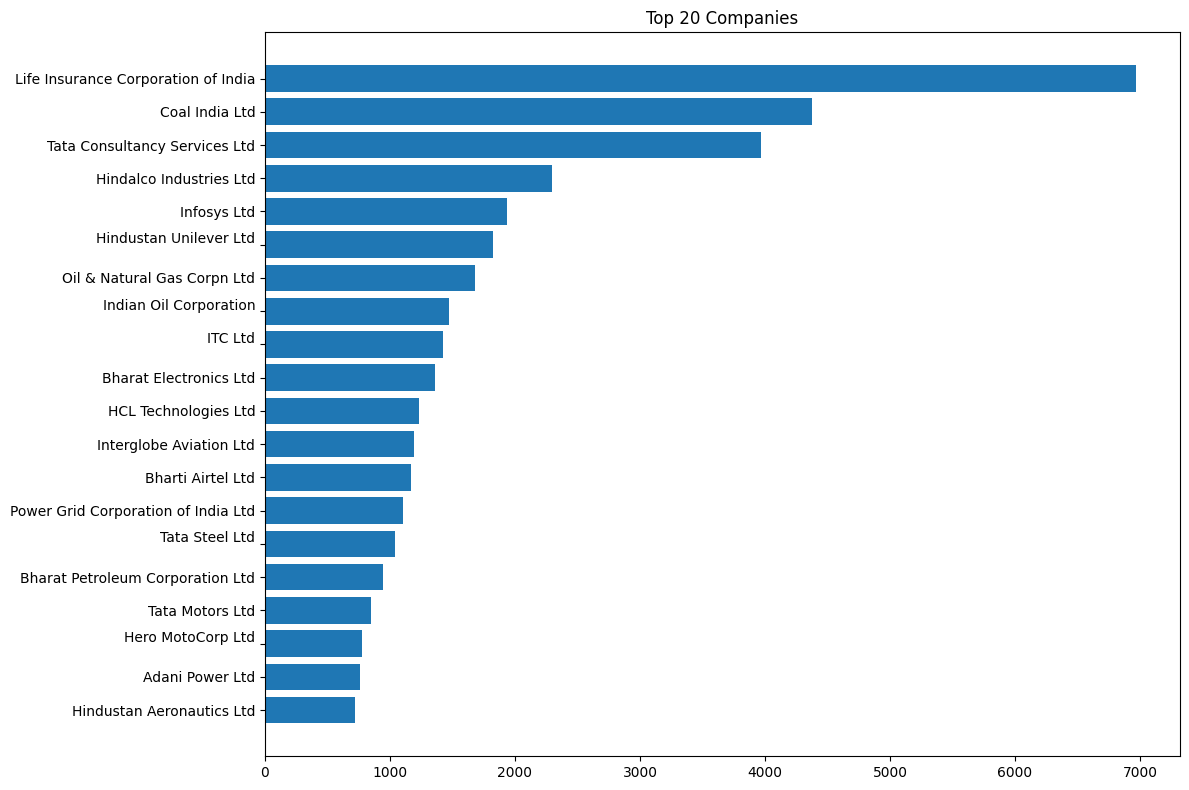

In [6]:
import matplotlib.pyplot as plt

top20 = ranking.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20.index,
    top20["composite_quality_score"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Companies")

plt.tight_layout()

plt.show()